In [1]:
import pandas as pd

In [3]:
data=pd.read_csv("data_donnees_2021_ind_v2.csv")

In [4]:
# Sélection des colonnes pertinentes pour l'analyse
df=data[["HHTYPE","HHInc_AT","SHELCO","HHSIZE","PR","DTYPE","BedRm"]]

In [5]:
# Filtrage des provinces de l'Ontario (PR=35) et de la Colombie Britannique (PR=59)
df = df[df["PR"].isin([35, 59])]

In [6]:
# Vérification de l'existence des valeurs manquantes
df.isnull().values.any()

np.False_

In [7]:
# Dictionnaire de correspondance
province_map = {
    35: "Ontario",
    59: "C-B"}

# Remplacer les valeurs de la colonne PR
df = df.copy()
df['PR'] = df['PR'].map(province_map)

#Renommer la colonne HHTYPE
df.rename(columns={"HHTYPE": "Type de ménage"}, inplace=True)

# Mapper les codes de revenu vers les médianes

income_map = {
    1: 1000,       
    2: (2000 + 4999)//2,   
    3: (5000 + 6999)//2,   
    4: (7000 + 9999)//2,   
    5: (10000 + 11999)//2, 
    6: (12000 + 14999)//2, 
    7: (15000 + 16999)//2, 
    8: (17000 + 19999)//2, 
    9: (20000 + 24999)//2, 
    10: (25000 + 29999)//2,
    11: (30000 + 34999)//2,
    12: (35000 + 39999)//2,
    13: (40000 + 44999)//2,
    14: (45000 + 49999)//2,
    15: (50000 + 54999)//2,
    16: (55000 + 59999)//2,
    17: (60000 + 64999)//2,
    18: (65000 + 69999)//2,
    19: (70000 + 74999)//2,
    20: (75000 + 79999)//2,
    21: (80000 + 84999)//2,
    22: (85000 + 89999)//2,
    23: (90000 + 94999)//2,
    24: (95000 + 99999)//2,
    25: (100000 + 109999)//2, 
    26: (110000 + 119999)//2, 
    27: (120000 + 134999)//2, 
    28: (135000 + 149999)//2,
    29: (150000 + 174999)//2,  
    30: (175000 + 199999)//2,  
    31: (200000 + 249999)//2, 
    32: 275000,
     # 88 Non disponible
}
df = df.copy()
df["HHInc_AT_median"] = df["HHInc_AT"].map(income_map)

In [8]:
# Suppression des lignes avec revenus non disponibles
df = df.dropna(subset=["HHInc_AT_median"])

In [9]:
# Création d'une nouvelle variable ratio_logement_revenu
df["ratio_logement_revenu"] = (df["SHELCO"] * 12) / df["HHInc_AT_median"]

Q1 = 0.123, Q3 = 0.308, IQR = 0.185
Borne inférieure = -0.154, Borne supérieure = 0.585


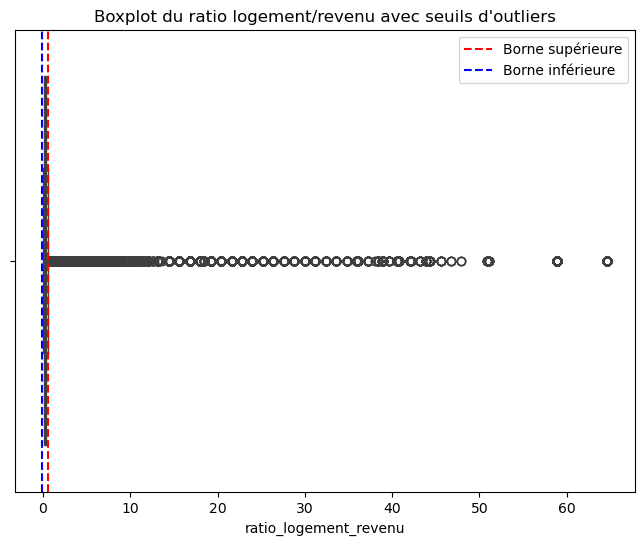

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul des quartiles et de l’IQR
Q1 = df['ratio_logement_revenu'].quantile(0.25)
Q3 = df['ratio_logement_revenu'].quantile(0.75)
IQR = Q3 - Q1

borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

print(f"Q1 = {Q1:.3f}, Q3 = {Q3:.3f}, IQR = {IQR:.3f}")
print(f"Borne inférieure = {borne_inf:.3f}, Borne supérieure = {borne_sup:.3f}")

# Visualisation avec un boxplot
plt.figure(figsize=(8,6))
sns.boxplot(x=df['ratio_logement_revenu'])
plt.axvline(borne_sup, color="red", linestyle="--", label="Borne supérieure")
plt.axvline(borne_inf, color="blue", linestyle="--", label="Borne inférieure")
plt.legend()
plt.title("Boxplot du ratio logement/revenu avec seuils d'outliers")
plt.show()


In [11]:
# Catégorisation selon le seuil d'abordabilité de 30%
def categoriser_ratio(x):
    if x <= 0.30:
        return "Abordable"
    elif 0.30 < x <= 1.00:
        return "Non abordable (charge élevée)"
    else:
        return "Dépassement du revenu"

df["categorie_ratio"] = df["ratio_logement_revenu"].apply(categoriser_ratio)

# Vérification de la répartition des catégories
df["categorie_ratio"].value_counts(normalize=True).round(3)

categorie_ratio
Abordable                        0.738
Non abordable (charge élevée)    0.237
Dépassement du revenu            0.025
Name: proportion, dtype: float64

In [12]:
# Compter le nombre de ménages par province et par catégorie
counts = df.groupby(["PR", "categorie_ratio"]).size().reset_index(name="nb_menages")

# Calculer la proportion dans chaque province
total_par_province = df.groupby("PR").size().reset_index(name="total_menages")
# Fusionner pour calculer la proportion
stats_province = counts.merge(total_par_province, on="PR")
stats_province["proportion"] = (stats_province["nb_menages"] / stats_province["total_menages"]).round(3)

# Affichage final
stats_province = stats_province[["PR", "categorie_ratio", "nb_menages", "proportion"]]
print(stats_province)


        PR                categorie_ratio  nb_menages  proportion
0      C-B                      Abordable       96751       0.731
1      C-B          Dépassement du revenu        4172       0.032
2      C-B  Non abordable (charge élevée)       31514       0.238
3  Ontario                      Abordable      279976       0.741
4  Ontario          Dépassement du revenu        8634       0.023
5  Ontario  Non abordable (charge élevée)       89446       0.237


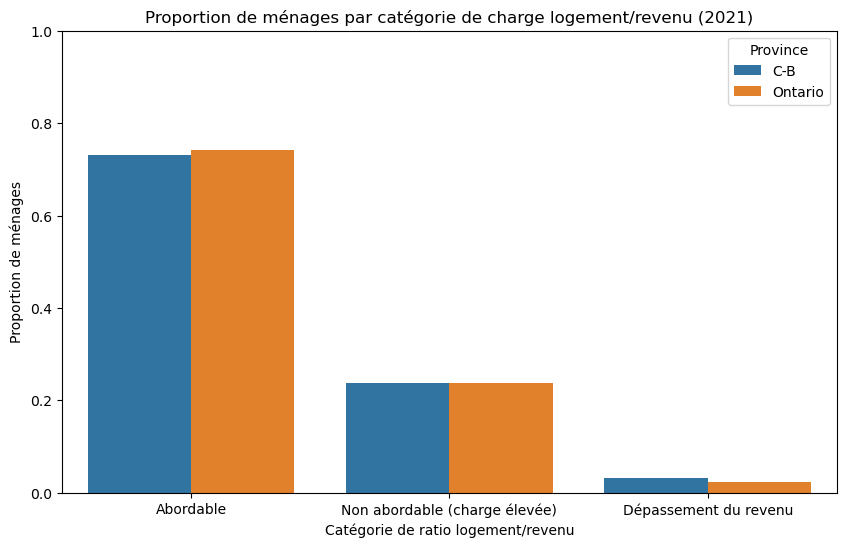

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Statistiques déjà calculées
stats_data = {
    "PR": ["C-B", "C-B", "C-B", "Ontario", "Ontario", "Ontario"],
    "categorie_ratio": ["Abordable", "Non abordable (charge élevée)", "Dépassement du revenu",
                        "Abordable", "Non abordable (charge élevée)", "Dépassement du revenu"],
    "proportion": [0.731, 0.238, 0.032, 0.741, 0.237, 0.023]
}

import pandas as pd
stats_df = pd.DataFrame(stats_data)

# Création du graphique
plt.figure(figsize=(10,6))
sns.barplot(data=stats_df, x="categorie_ratio", y="proportion", hue="PR")
plt.title("Proportion de ménages par catégorie de charge logement/revenu (2021)")
plt.ylabel("Proportion de ménages")
plt.xlabel("Catégorie de ratio logement/revenu")
plt.ylim(0,1)
plt.legend(title="Province")
plt.show()


In [14]:
# Statistiques par province et type de ménage
stats_type_menage = df.groupby(["PR", "Type de ménage", "categorie_ratio"]).agg(
    nb_menages=("categorie_ratio", "count")
).reset_index()

# Calcul des proportions pour chaque type de ménage dans chaque province
stats_type_menage["proportion"] = stats_type_menage.groupby(["PR", "Type de ménage"])["nb_menages"].transform(lambda x: x / x.sum())

stats_type_menage


,PR,Type de ménage,categorie_ratio,nb_menages,proportion
0,C-B,1,Abordable,23580,0.809725
1,C-B,1,Dépassement du revenu,605,0.020775
2,C-B,1,Non abordable (charge élevée),4936,0.169500
3,C-B,2,Abordable,35822,0.753434
4,C-B,2,Dépassement du revenu,1038,0.021832
5,C-B,2,Non abordable (charge élevée),10685,0.224734
6,C-B,3,Abordable,2440,0.816873
7,C-B,3,Dépassement du revenu,46,0.015400
8,C-B,3,Non abordable (charge élevée),501,0.167727
9,C-B,4,Abordable,5276,0.781051


In [15]:
# Exclure les ménages avec type 88 (non disponible)
df = df[df["Type de ménage"] != 88].copy()

# Vérification
print("Types de ménage restants :", df["Type de ménage"].unique())


Types de ménage restants : [2 3 1 5 4 6 9 7 8]


In [16]:
# Statistiques par province et type de ménage
stats_type_menage = df.groupby(["PR", "Type de ménage", "categorie_ratio"]).agg(
    nb_menages=("categorie_ratio", "count")
).reset_index()

# Calculer la proportion pour chaque type de ménage dans chaque province
stats_type_menage["proportion"] = stats_type_menage.groupby(["PR", "Type de ménage"])["nb_menages"].transform(lambda x: x / x.sum())

stats_type_menage

,PR,Type de ménage,categorie_ratio,nb_menages,proportion
0,C-B,1,Abordable,23580,0.809725
1,C-B,1,Dépassement du revenu,605,0.020775
2,C-B,1,Non abordable (charge élevée),4936,0.169500
3,C-B,2,Abordable,35822,0.753434
4,C-B,2,Dépassement du revenu,1038,0.021832
5,C-B,2,Non abordable (charge élevée),10685,0.224734
6,C-B,3,Abordable,2440,0.816873
7,C-B,3,Dépassement du revenu,46,0.015400
8,C-B,3,Non abordable (charge élevée),501,0.167727
9,C-B,4,Abordable,5276,0.781051


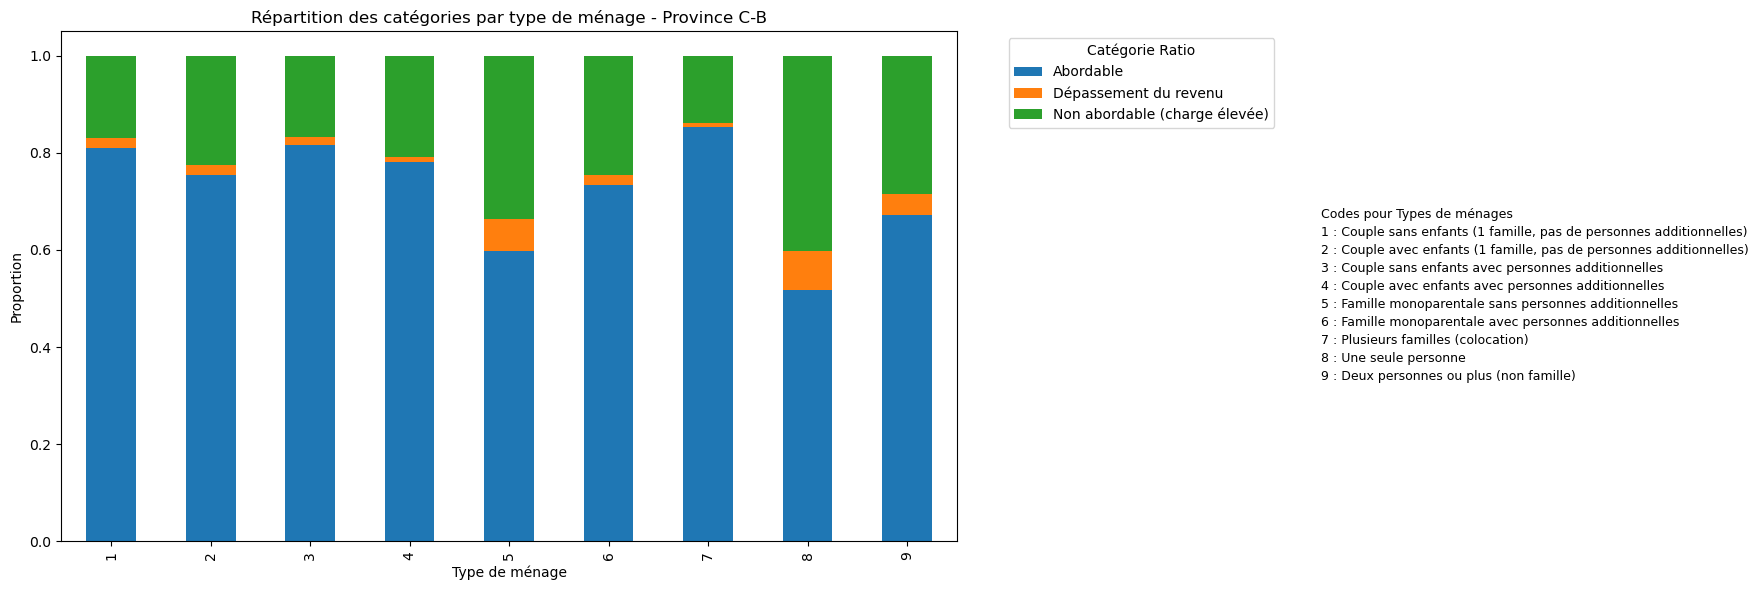

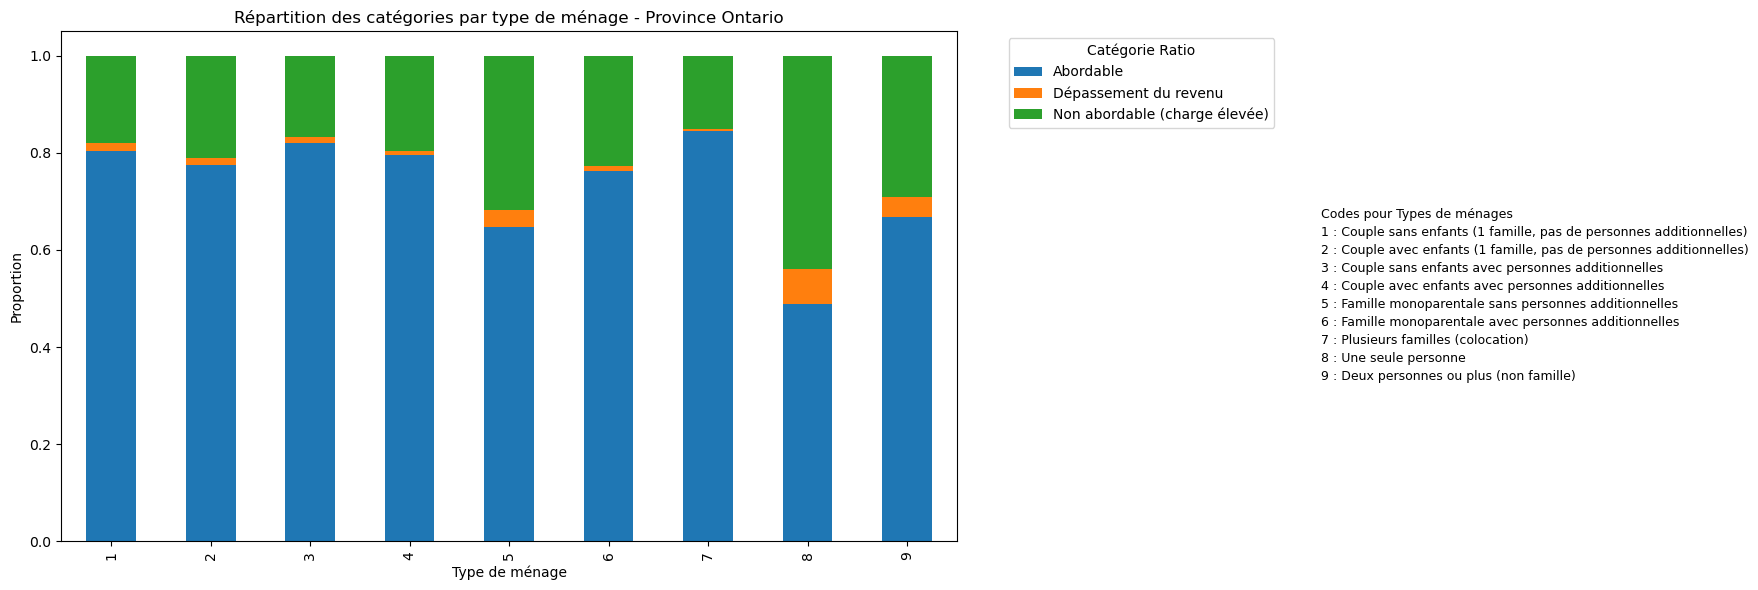

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Dictionnaire des explications pour Type de ménage
legende_type_menage = {
    1: "1 : Couple sans enfants (1 famille, pas de personnes additionnelles)",
    2: "2 : Couple avec enfants (1 famille, pas de personnes additionnelles)",
    3: "3 : Couple sans enfants avec personnes additionnelles",
    4: "4 : Couple avec enfants avec personnes additionnelles",
    5: "5 : Famille monoparentale sans personnes additionnelles",
    6: "6 : Famille monoparentale avec personnes additionnelles",
    7: "7 : Plusieurs familles (colocation)",
    8: "8 : Une seule personne",
    9: "9 : Deux personnes ou plus (non famille)"
}

# pivotons les données pour plus de clarté
pivot_df = stats_type_menage.pivot_table(
    index=["PR", "Type de ménage"],
    columns="categorie_ratio",
    values="proportion",
    fill_value=0
).reset_index()


# Génération du texte de la légende avec un titre
legende_title = "Codes pour Types de ménages"
legende_text = legende_title + "\n" + "\n".join([legende_type_menage[k] for k in sorted(legende_type_menage.keys())])

# Création des graphiques par province
for province in pivot_df["PR"].unique():
    subset = pivot_df[pivot_df["PR"] == province]
    subset = subset.set_index("Type de ménage")
    
    ax = subset.plot(
        kind="bar",
        stacked=True,
        figsize=(13, 6),
        title=f"Répartition des catégories par type de ménage - Province {province}"
    )
    
    plt.ylabel("Proportion")
    plt.xlabel("Type de ménage")
    plt.legend(title="Catégorie Ratio", bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Ajout de la légende explicative avec un titre
    plt.gcf().text(1.02, 0.5, legende_text, fontsize=9, va='center', ha='left', linespacing=1.5)

    plt.tight_layout()
    plt.show()


In [18]:
# Statistiques de base : moyenne et médiane du ratio logement/revenu
stats_ratio = (
    df.groupby(["PR", "Type de ménage"])["ratio_logement_revenu"]
      .agg(moyenne="mean", mediane="median", effectif="count")
      .reset_index()
)

# Tri par province et par moyenne décroissante pour faciliter la lecture
stats_ratio = stats_ratio.sort_values(by=["PR", "moyenne"], ascending=[True, False])

display(stats_ratio)


,PR,Type de ménage,moyenne,mediane,effectif
7,C-B,8,0.860354,0.288008,16233
4,C-B,5,0.784356,0.254120,10026
8,C-B,9,0.663759,0.229569,7013
1,C-B,2,0.418489,0.207570,47545
2,C-B,3,0.387579,0.168422,2987
0,C-B,1,0.364861,0.166958,29121
3,C-B,4,0.323506,0.193686,6755
5,C-B,6,0.305927,0.202107,2933
6,C-B,7,0.247785,0.168422,9629
16,Ontario,8,0.783354,0.305466,39275


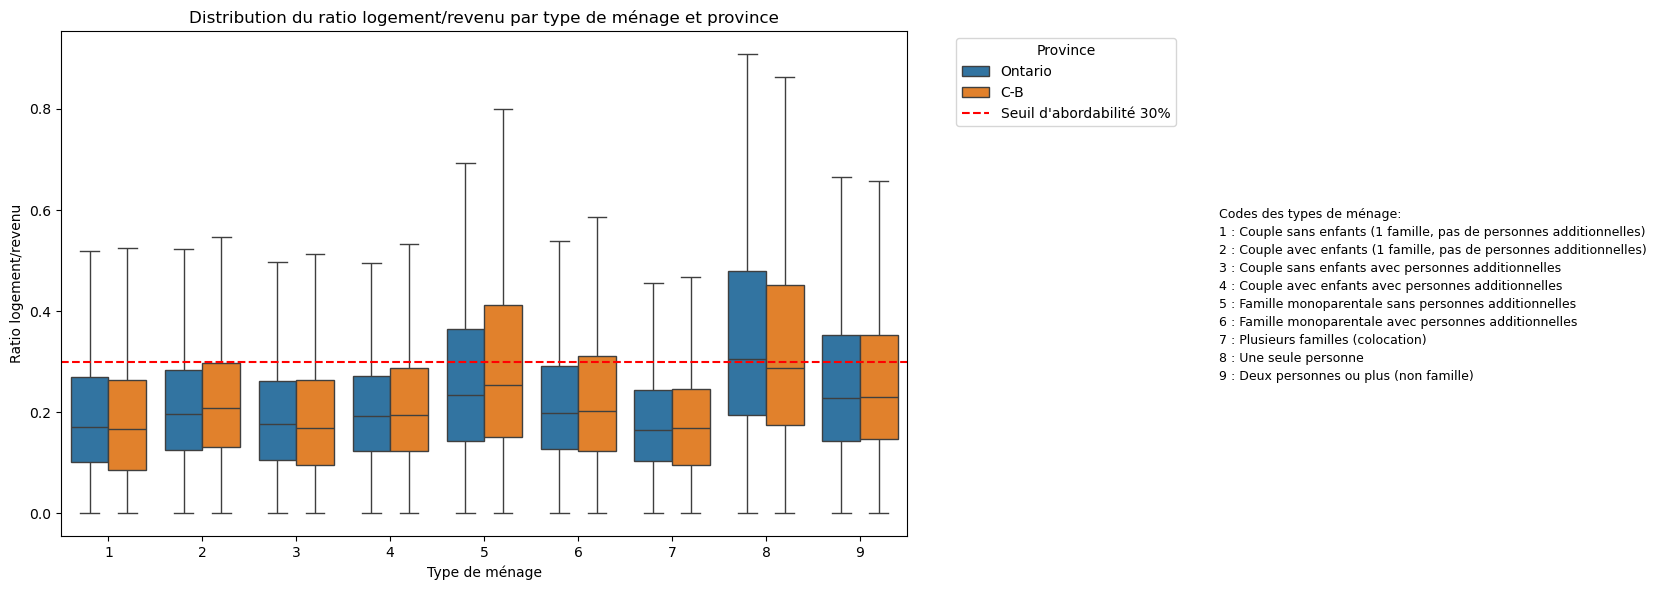

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

# Créer le boxplot
plt.figure(figsize=(12,6))
sns.boxplot(
    x="Type de ménage", 
    y="ratio_logement_revenu", 
    hue="PR", 
    data=df, 
    showfliers=False
)

# Ligne du seuil d'abordabilité
plt.axhline(0.3, color="red", linestyle="--", label="Seuil d'abordabilité 30%")

# Titres et axes
plt.title("Distribution du ratio logement/revenu par type de ménage et province")
plt.xlabel("Type de ménage")
plt.ylabel("Ratio logement/revenu")

# Légende des provinces (hue)
plt.legend(title="Province", bbox_to_anchor=(1.05, 1), loc='upper left')

# Ajouter la légende explicative pour les types de ménage sur le côté droit
legende_text = "Codes des types de ménage:\n" + "\n".join([v for k,v in sorted(legende_type_menage.items())])
plt.gcf().text(1.02, 0.5, legende_text, fontsize=9, va='center', ha='left', linespacing=1.5)

plt.tight_layout()
plt.show()


In [25]:
# Statistiques par nombre de chambres à coucher
stats_bedroom = (
    df.groupby(["PR", "BedRm"])["ratio_logement_revenu"]
      .agg(moyenne="mean", mediane="median", effectif="count")
      .reset_index()
)

display(stats_bedroom)


,PR,BedRm,moyenne,mediane,effectif
0,C-B,0,0.792587,0.287550,956
1,C-B,1,0.722939,0.261821,13728
2,C-B,2,0.508420,0.218184,30034
3,C-B,3,0.389408,0.192001,37440
4,C-B,4,0.458821,0.186667,27030
5,C-B,5,0.464050,0.198263,22962
6,C-B,8,0.482847,0.155430,92
7,Ontario,0,0.642637,0.277901,1691
8,Ontario,1,0.672774,0.278713,29491
9,Ontario,2,0.503234,0.230404,65486


In [26]:
# Supprimer les observations dont le code BedRm = 8 (données manquantes)
df_clean = df[df["BedRm"] != 8].copy()


In [27]:
stats_bedroom = (
    df_clean.groupby(["PR", "BedRm"])["ratio_logement_revenu"]
        .agg(moyenne="mean", mediane="median", effectif="count")
        .reset_index()
)

display(stats_bedroom)


,PR,BedRm,moyenne,mediane,effectif
0,C-B,0,0.792587,0.287550,956
1,C-B,1,0.722939,0.261821,13728
2,C-B,2,0.508420,0.218184,30034
3,C-B,3,0.389408,0.192001,37440
4,C-B,4,0.458821,0.186667,27030
5,C-B,5,0.464050,0.198263,22962
6,Ontario,0,0.642637,0.277901,1691
7,Ontario,1,0.672774,0.278713,29491
8,Ontario,2,0.503234,0.230404,65486
9,Ontario,3,0.326352,0.192002,135747


In [28]:
# Corrélation entre ratio_logement_revenu et BedRm

df_clean["ratio_logement_revenu"].corr(df_clean["BedRm"])


np.float64(-0.0338755627570244)

C:\Users\Owner\AppData\Local\Temp\ipykernel_39084\1004294835.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


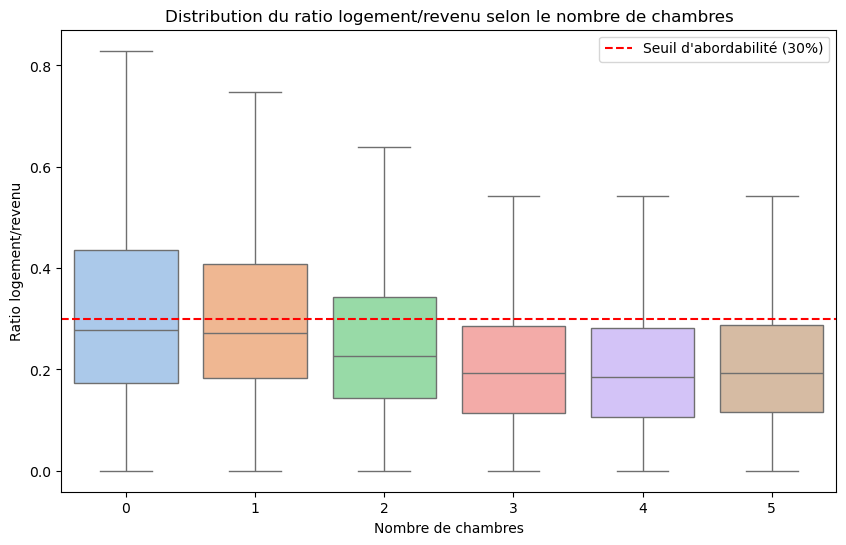

In [30]:
# Visualisation de la distribution du ratio selon la taille du logement

plt.figure(figsize=(10,6))
sns.boxplot(
    data=df_clean,
    x="BedRm",
    y="ratio_logement_revenu",
    showfliers=False,
    palette="pastel"
)
plt.axhline(0.3, color='red', linestyle='--', label='Seuil d\'abordabilité (30%)')
plt.title("Distribution du ratio logement/revenu selon le nombre de chambres")
plt.xlabel("Nombre de chambres")
plt.ylabel("Ratio logement/revenu")
plt.legend()
plt.show()


In [32]:
# Calculer la corrélation par province
correlations_province = df_clean.groupby("PR").apply(
    lambda x: x["ratio_logement_revenu"].corr(x["BedRm"])
).reset_index(name="corr_BedRm_ratio")

print(correlations_province)


        PR  corr_BedRm_ratio
0      C-B         -0.021255
1  Ontario         -0.040322


C:\Users\Owner\AppData\Local\Temp\ipykernel_39084\4012162157.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  correlations_province = df_clean.groupby("PR").apply(
